# Parameter Choice for Kalman Filter in Rayleigh Fading Channel

## Introduction
The performance of the Kalman filter is highly dependent on the choice of its parameters. This notebook explores the impact of the model parameters, specifically `alpha`, `sigma`, and the Signal-to-Noise Ratio (SNR), on the accuracy of the channel estimation in a Rayleigh fading environment. Our goal is to understand how these parameters influence the Mean Squared Error (MSE) of the Kalman filter and to provide insights into their selection.

# 1.Varying the parameter σᵤ  


After testing the filter for several values of the process noise parameter σᵤ in the kalman_rayleigh.ipynb notebook. We observed that the parameter $\sigma_u$ has an impact on the prediction of the filter.

**Effect of σᵤ**

- When **σᵤ is small (e.g., 0.1)**, the filter trusts the state model too much. Estimates look smooth but lag behind the true state, and the confidence bands are too narrow (underestimate uncertainty).  
- When **σᵤ is large (e.g., 1.0)**, the filter trusts the observations more. The estimate follows the true state closely, with wider but more realistic confidence intervals.

This explains why RMSE decreases as σᵤ increases up to a point: the filter adapts faster and avoids lag. However, if σᵤ is too large, the filter may overfit to noise. The algorithm therefore balances:
- **Model trust** (small σᵤ → smoother, but biased estimates)  
- **Observation trust** (large σᵤ → responsive, but noisier estimates)

**Conclusion:** there exists an optimal σᵤ where the filter achieves the best compromise between tracking ability and noise rejection, which is visible in both the RMSE and the confidence intervals.  
This motivates the use of the **log-likelihood approach** in the next section, which provides a principled way to estimate the best σᵤ (and other parameters) automatically.

# 2. Selecting σᵤ by prediction likelihood

We select σᵤ by maximizing the **prediction likelihood** from the Kalman filter.  
For each candidate σᵤ (with fixed ρ, σᵥ), we run the filter to obtain innovations εₖ and their variances Γₖ.  
Assuming εₖ ~ 𝓝(0, Γₖ) (from algo 5.2.9), the (negative) log-likelihood is
$$
\text{NLL}(\sigma_u) = \tfrac12 \sum_k \big(\log \Gamma_k + \varepsilon_k^2/\Gamma_k\big) + \text{const}.
$$

**Effect**

- By maximizing this log-likelihood, we find the parameters that make the observed data most consistent with the model.  
- This provides a principled way to tune σᵤ rather than relying on trial-and-error.  
- In practice, we search over candidate values (grid search) or use iterative algorithms (e.g. EM) to find the optimum.

**Conclusion**

Using the log-likelihood aligns the filter with the actual statistics of the data. This ensures that innovations are well-behaved (approximately standard normal when standardized), and that **the chosen parameters yield the best balance between tracking and noise rejection.**

# 3. Implementation

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from typing import Tuple 

In [28]:
def simulate_system(n: int, rho: float, sigma_u: float, sigma_v: float) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
      # Generate random bits (fair Bernoulli)
    C_k = np.random.choice([-1, 1], size=n)
    
    # Generate fading coefficients W_k (AR(1) process)
    W_k = np.zeros(n)
    U_k = np.random.normal(0, sigma_u, n)
    W_k[0] = np.random.normal(0, sigma_u/np.sqrt(1 - rho**2))  # Stationary initialization
    for k in range(1, n):
        W_k[k] = rho * W_k[k-1] + U_k[k]
    
    # Generate observations Y_k
    V_k = np.random.normal(0, sigma_v, n)
    Y_k = W_k * C_k + V_k
    
    return C_k, W_k, Y_k

In [29]:
def kalman_filter(Y_k: np.ndarray, C_k: np.ndarray, 
                  rho: float, sigma_u: float, sigma_v: float) -> Tuple[np.ndarray, np.ndarray]:
    n = len(Y_k)
    
    # Initialize
    W_k_hat = np.zeros(n)
    Sigma_k = np.zeros(n)
    
    # Initial conditions (stationary distribution)
    W_k_hat[0] = 0  # Initial prediction
    Sigma_k[0] = sigma_u**2 / (1 - rho**2)  # Stationary variance
    
    for k in range(n-1):
        # Innovation (Eq 5.57)
        epsilon_k = Y_k[k] - C_k[k] * W_k_hat[k]
        
        # Innovation covariance (Eq 5.58)
        Gamma_k = C_k[k]**2 * Sigma_k[k] + sigma_v**2
        
        # Kalman gain (Eq 5.59)
        H_k = rho * Sigma_k[k] * C_k[k] / Gamma_k
        
        # State prediction (Eq 5.60)
        W_k_hat[k+1] = rho * W_k_hat[k] + H_k * epsilon_k
        
        # Error covariance prediction (Eq 5.61)
        Sigma_k[k+1] = (rho - H_k * C_k[k])**2 * Sigma_k[k] + sigma_u**2
        
    return W_k_hat, Sigma_k

In [33]:
def plot_results(C_k: np.ndarray, W_k: np.ndarray, Y_k: np.ndarray, 
                W_k_hat: np.ndarray, Sigma_k: np.ndarray, 
                sigma_u: float, sigma_v: float) -> None:
   
    n = len(C_k)
    time = np.arange(n)
    
    plt.figure(figsize=(15, 5))    
    # Plot 3: True vs Estimated fading coefficients
    plt.subplot(3, 1, 3)
    plt.plot(time, W_k, 'g-', label='True $W_k$', linewidth=2)
    plt.plot(time, W_k_hat, 'r--', label='Estimated $\hat{W}_k$', linewidth=1.5)

    # Confidence interval
    std_dev = np.sqrt(Sigma_k)
    plt.fill_between(time, 
                    W_k_hat - 2*std_dev, 
                    W_k_hat + 2*std_dev, 
                    color='r', alpha=0.2, label='95% CI')
    
    plt.title('True vs Estimated Fading Coefficients')
    plt.ylabel('Fading coefficient')
    plt.legend()
    plt.grid(True)

    z_k = (W_k[1:] - W_k_hat[1:]) / np.sqrt(Sigma_k[1:])
    t_z = time[1:]    
    plt.tight_layout()
    plt.show()
    

<>:12: SyntaxWarning: invalid escape sequence '\h'
<>:12: SyntaxWarning: invalid escape sequence '\h'
/tmp/ipykernel_9615/1475969770.py:12: SyntaxWarning: invalid escape sequence '\h'
  plt.plot(time, W_k_hat, 'r--', label='Estimated $\hat{W}_k$', linewidth=1.5)


In [34]:
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------
# Metrics (work with your outputs)
# ----------------------------
def rmse(w_true: np.ndarray, w_hat: np.ndarray) -> float:
    return float(np.sqrt(np.mean((w_true - w_hat)**2)))

def nrmse(w_true: np.ndarray, w_hat: np.ndarray, how: str = "std") -> float:
    if how == "std":
        scale = np.std(w_true)
    elif how == "range":
        scale = (np.max(w_true) - np.min(w_true)) + 1e-12
    else:
        raise ValueError("how must be 'std' or 'range'")
    return rmse(w_true, w_hat) / (scale + 1e-12)

# ----------------------------
# Innovation log-likelihood
# (same equations as your kalman_filter, but returns eps & Gamma)
# ----------------------------
def kf_innovation_loglik(Y_k: np.ndarray, C_k: np.ndarray,
                         rho: float, sigma_u: float, sigma_v: float) -> float:
    n = len(Y_k)
    # state variance (k|k) at step 0 (stationary)
    Sigma_k = sigma_u**2 / (1.0 - rho**2)
    W_hat = 0.0  # \hat W_0|0

    loglik = 0.0
    for k in range(n):
        # innovation
        eps_k = Y_k[k] - C_k[k] * W_hat
        # innovation variance
        Gamma_k = (C_k[k]**2) * Sigma_k + sigma_v**2
        # accumulate log-likelihood (up to constant)
        loglik += -0.5 * (np.log(Gamma_k) + (eps_k**2)/Gamma_k)

        # gain and time update (your equations)
        H_k = rho * Sigma_k * C_k[k] / Gamma_k
        W_hat = rho * W_hat + H_k * eps_k
        Sigma_k = (rho - H_k * C_k[k])**2 * Sigma_k + sigma_u**2

    return float(loglik)

# ----------------------------
# Sweep σ_u: NRMSE and log-likelihood
# (uses your kalman_filter for estimates)
# ----------------------------
def sweep_sigma_u_and_plot(C_k, W_k, Y_k, rho, sigma_v, sigma_u_grid,
                           use_tail_rmse: bool = False):
    ll_vals, nrmse_vals, rmse_vals = [], [], []
    best = {"sigma_u": None, "loglik": -np.inf, "nrmse": np.inf, "rmse": np.inf}

    for su in sigma_u_grid:
        # run your KF to get estimate for metrics
        W_hat, Sig = kalman_filter(Y_k, C_k, rho, su, sigma_v)

        if use_tail_rmse:
            # if you prefer ignoring first steps (warm-up)
            r = float(np.sqrt(np.mean((W_k[2:] - W_hat[2:])**2)))
            nr = r / (np.std(W_k[2:]) + 1e-12)
        else:
            r = rmse(W_k, W_hat)
            nr = nrmse(W_k, W_hat)

        # compute innovation log-likelihood with the same params
        ll = kf_innovation_loglik(Y_k, C_k, rho, su, sigma_v)

        rmse_vals.append(r); nrmse_vals.append(nr); ll_vals.append(ll)
        if ll > best["loglik"]:
            best.update({"sigma_u": su, "loglik": ll, "rmse": r, "nrmse": nr, "W_hat": W_hat, "Sig": Sig})

    # plots
    su = np.array(sigma_u_grid)
    ll_vals = np.array(ll_vals)
    nrmse_vals = np.array(nrmse_vals)

    fig, ax = plt.subplots(1, 2, figsize=(11,4))
    ax[0].plot(su, nrmse_vals, marker='o')
    ax[0].axvline(best["sigma_u"], ls='--', alpha=0.7, label='LL optimum')
    ax[0].set_xlabel(r'$\sigma_u$'); ax[0].set_ylabel('NRMSE (by std of W)')
    ax[0].set_title('NRMSE vs $\sigma_u$'); ax[0].grid(True, alpha=0.3); ax[0].legend()

    ax[1].plot(su, ll_vals, marker='o')
    ax[1].axvline(best["sigma_u"], ls='--', alpha=0.7)
    ax[1].set_xlabel(r'$\sigma_u$'); ax[1].set_ylabel('Log-likelihood')
    ax[1].set_title('Prediction log-likelihood vs $\sigma_u$'); ax[1].grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()

    return best



<>:83: SyntaxWarning: invalid escape sequence '\s'
<>:88: SyntaxWarning: invalid escape sequence '\s'
<>:83: SyntaxWarning: invalid escape sequence '\s'
<>:88: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_9615/2225273511.py:83: SyntaxWarning: invalid escape sequence '\s'
  ax[0].set_title('NRMSE vs $\sigma_u$'); ax[0].grid(True, alpha=0.3); ax[0].legend()
/tmp/ipykernel_9615/2225273511.py:88: SyntaxWarning: invalid escape sequence '\s'
  ax[1].set_title('Prediction log-likelihood vs $\sigma_u$'); ax[1].grid(True, alpha=0.3)


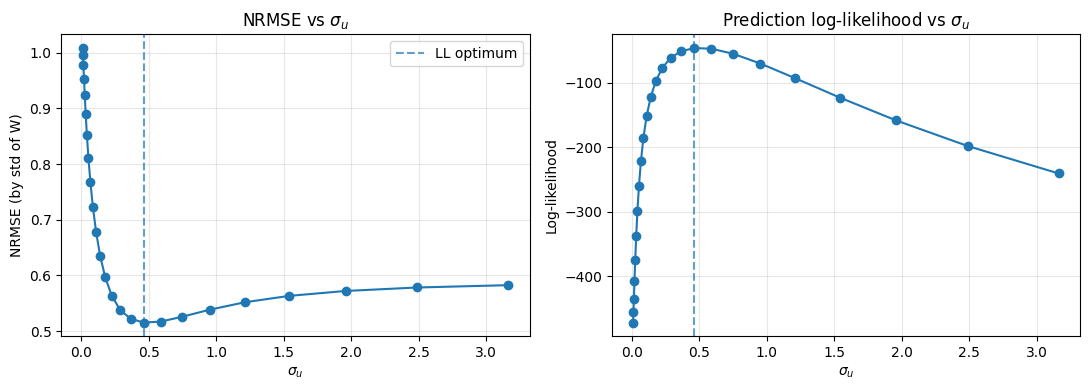

Best σ_u (by LL) = 0.4642 | NRMSE=0.515 | RMSE=0.598


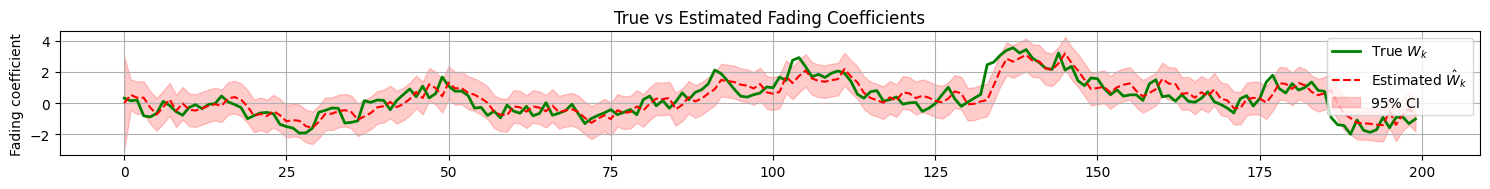

In [35]:
np.random.seed(42)
n = 200
rho = 0.95
sigma_v = 0.5
sigma_u_true = 0.5  # used only to simulate
C_k, W_k, Y_k = simulate_system(n, rho, sigma_u_true, sigma_v)

sigma_u_grid = np.logspace(-2, 0.5, 25)  # 0.01 ... ~3.16
best = sweep_sigma_u_and_plot(C_k, W_k, Y_k, rho, sigma_v, sigma_u_grid)

print(f"Best σ_u (by LL) = {best['sigma_u']:.4f} | NRMSE={best['nrmse']:.3f} | RMSE={best['rmse']:.3f}")

# Replot your 4-panel figure with the best σ_u using your own function:
plot_results(C_k, W_k, Y_k, best["W_hat"], best["Sig"], sigma_u=best["sigma_u"], sigma_v=sigma_v)

The 2 plots above tell us what value to chose for our $\sigma_u$.

# 4. General parameter Selection via Log-Likelihood

**Principle**

At each step, the filter produces an innovation εₖ (the difference between observation and one-step prediction) with variance Γₖ.  
If the parameters (ρ, σᵤ, σᵥ) are correct, these innovations should behave like independent 𝓝(0, Γₖ) random variables.  
This leads to the log-likelihood:
$$
\log L(\rho,\sigma_u,\sigma_v) = -\tfrac12 \sum_k \left( \log \Gamma_k + \frac{\varepsilon_k^2}{\Gamma_k} \right) + \text{const}.
$$


Best (MLE) params:
  rho     = 0.9300
  sigma_u = 0.5135
  sigma_v = 0.6105
  loglik  = -47.91
  RMSE    = 0.603
  NRMSE   = 0.518


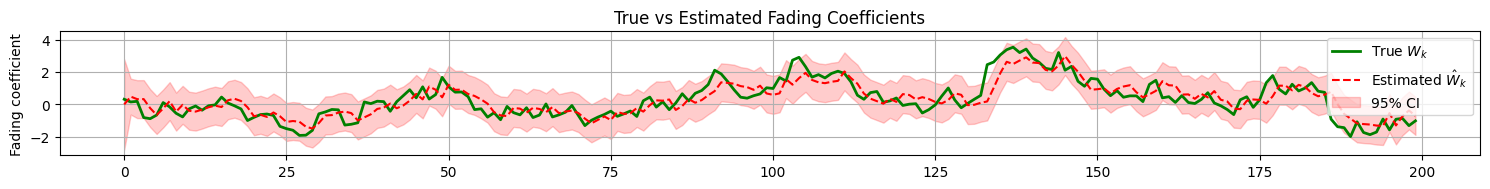

In [37]:
import numpy as np
import itertools
import matplotlib.pyplot as plt

# ---------- Metrics ----------
def rmse(a, b): 
    return float(np.sqrt(np.mean((a - b)**2)))

def nrmse(a, b, how="std"):
    if how == "std":
        scale = np.std(a) + 1e-12
    elif how == "range":
        scale = (np.max(a) - np.min(a)) + 1e-12
    else:
        raise ValueError("how must be 'std' or 'range'")
    return rmse(a, b) / scale

# ---------- Log-likelihood via innovations (uses same equations as your KF) ----------
def kf_innovation_loglik(Y_k, C_k, rho, sigma_u, sigma_v):
    """
    Compute log-likelihood using the innovation (prediction-error) decomposition.
    Matches Eq. (5.57)-(5.63) in the book.
    We re-run the scalar KF equations internally to get eps_k and Gamma_k.
    """
    n = len(Y_k)
    # initial (k|k) variance at stationarity
    Sigma_k = sigma_u**2 / (1.0 - rho**2)
    W_hat = 0.0  # \hat W_{0|0}
    ll = 0.0

    for k in range(n):
        # innovation and its variance
        eps_k = Y_k[k] - C_k[k] * W_hat
        Gamma_k = (C_k[k]**2) * Sigma_k + sigma_v**2

        ll += -0.5 * (np.log(Gamma_k) + (eps_k**2)/Gamma_k)

        # gain and one-step prediction update (your exact equations)
        H_k = rho * Sigma_k * C_k[k] / Gamma_k
        W_hat = rho * W_hat + H_k * eps_k
        Sigma_k = (rho - H_k * C_k[k])**2 * Sigma_k + sigma_u**2

    return float(ll)

# ---------- 3D grid search over (rho, sigma_u, sigma_v) ----------
def grid_search_params(C_k, W_k, Y_k, 
                       rhos, sigmas_u, sigmas_v, 
                       use_tail: bool = True):
    """
    Returns the MLE triple and diagnostics (NRMSE, RMSE, loglik).
    Keeps compatibility with your kalman_filter() and plot_results().
    """
    best = {"rho": None, "sigma_u": None, "sigma_v": None, 
            "loglik": -np.inf, "rmse": None, "nrmse": None,
            "W_hat": None, "Sigma": None}

    for rho, su, sv in itertools.product(rhos, sigmas_u, sigmas_v):
        # log-likelihood from innovations (principled objective)
        ll = kf_innovation_loglik(Y_k, C_k, rho, su, sv)

        # run YOUR filter to get the estimate for metrics/plots
        W_hat, Sigma = kalman_filter(Y_k, C_k, rho, su, sv)

        if use_tail:
            # ignore first steps (warmup) for error metric, if you prefer
            err_rmse = float(np.sqrt(np.mean((W_k[2:] - W_hat[2:])**2)))
            err_nrmse = err_rmse / (np.std(W_k[2:]) + 1e-12)
        else:
            err_rmse = rmse(W_k, W_hat)
            err_nrmse = nrmse(W_k, W_hat, "std")

        if ll > best["loglik"]:
            best.update({"rho": rho, "sigma_u": su, "sigma_v": sv,
                         "loglik": ll, "rmse": err_rmse, "nrmse": err_nrmse,
                         "W_hat": W_hat, "Sigma": Sigma})
    return best

# ---------- Example driver (adjust grids to your problem size) ----------
# Example grids (coarse -> refine around the winner)
rhos_grid     = np.linspace(0.80, 0.99, 20)
sigmas_u_grid = np.logspace(-2, 0.5, 20)   # 0.01 .. ~3.16
sigmas_v_grid = np.logspace(-2, 0.5, 15)   # 0.01 .. ~3.16

best = grid_search_params(C_k, W_k, Y_k, rhos_grid, sigmas_u_grid, sigmas_v_grid)

print(f"Best (MLE) params:")
print(f"  rho     = {best['rho']:.4f}")
print(f"  sigma_u = {best['sigma_u']:.4f}")
print(f"  sigma_v = {best['sigma_v']:.4f}")
print(f"  loglik  = {best['loglik']:.2f}")
print(f"  RMSE    = {best['rmse']:.3f}")
print(f"  NRMSE   = {best['nrmse']:.3f}")

# Re-plot with your function at the MLE point
plot_results(C_k, W_k, Y_k, best["W_hat"], best["Sigma"], 
             sigma_u=best["sigma_u"], sigma_v=best["sigma_v"])


Thanks to the EM algorithm, we now have the set of optimal parameters.

# 6.Error Analyis

In [39]:
import matplotlib.pyplot as plt
from scipy.stats import norm

def plot_standardized_innovations(Y_k, C_k, rho, sigma_u, sigma_v):
    n = len(Y_k)
    Sigma_k = sigma_u**2 / (1.0 - rho**2)
    W_hat = 0.0
    z_vals = []

    for k in range(n):
        eps_k = Y_k[k] - C_k[k] * W_hat
        Gamma_k = (C_k[k]**2) * Sigma_k + sigma_v**2
        z_vals.append(eps_k / np.sqrt(Gamma_k))

        H_k = rho * Sigma_k * C_k[k] / Gamma_k
        W_hat = rho * W_hat + H_k * eps_k
        Sigma_k = (rho - H_k * C_k[k])**2 * Sigma_k + sigma_u**2

    z_vals = np.array(z_vals)

    # Plot histogram with Gaussian overlay
    plt.figure(figsize=(7,4))
    plt.hist(z_vals, bins=13, density=True, alpha=0.6, color="m", label="Standardized innovations")
    x = np.linspace(-4,4,200)
    plt.plot(x, norm.pdf(x,0,1), "k--", lw=2, label="N(0,1) reference")
    plt.title("Histogram of standardized innovations $z_k$")
    plt.xlabel("z")
    plt.ylabel("Density")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    print(f"mean(z) = {np.mean(z_vals):.3f}, var(z) = {np.var(z_vals):.3f}")


ModuleNotFoundError: No module named 'scipy'

In [ ]:
plot_standardized_innovations(Y_k, C_k, rho=best["rho"], 
                              sigma_u=best["sigma_u"], sigma_v=best["sigma_v"])
